# Replicating the Italian day-ahead market with OpenEUPHEMIA

[EUPHEMIA](https://www.nemo-committee.eu/sdac) clears the European day-ahead
market: it maximizes economic welfare over every submitted order subject to
the network constraints, and the outcome — a price per zone and a flow per
link — settles billions of euros of energy a year. The algorithm is publicly
described, but its implementation is closed.

This notebook rebuilds one country of it from published data alone. We
assemble the seven Italian bidding zones step by step — topology, bid
curves, transfer capacities, boundary conditions — clear the market, and
compare both outcomes against what GME actually published.

Prices turn out to be the easy half: **every zone-hour of April 2025 exact**.
Flows are the interesting half, because welfare maximization genuinely does
not determine them — we will see what does.

In [1]:
import pathlib
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/rebase-energy/OpenEUPHEMIA.git
    %pip install -q "./OpenEUPHEMIA[notebook]"
    ROOT = pathlib.Path("OpenEUPHEMIA")
else:
    ROOT = next(
        parent
        for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
        if (parent / "data" / "italy").is_dir()
    )

sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "italy" / "2025-04"
print("repository root:", ROOT)

repository root: /Users/sebaheg/Documents/Github/OpenEUPHEMIA


## 1. The inputs

Five tidy tables, all derived from GME's public publications and committed
to the repository (see [`data/italy`](../data/italy)). Data collection is
deliberately not part of the library — OpenEUPHEMIA is about building,
closing, and clearing markets.

| Table | What it is | Role |
|---|---|---|
| `bid-curves` | the aggregated order book: one row per zone, hour, side, price step | input |
| `transfer-capacities` | the published limit of every edge, internal and cross-border | input |
| `published-prices` | the prices GME published, for the Italian zones **and** their neighbours | neighbours in, Italy is the target |
| `published-exchanges` | the scheduled exchange on each of the 12 borders | input (see §5) |
| `published-flows` | the scheduled flow on each of the 6 internal links | **target only** |

Nothing we are trying to predict is ever fed to the solver: the Italian
prices and the internal flows are held back for scoring.

In [2]:
import pandas as pd

bid_curves = pd.read_csv(DATA / "bid-curves.csv.gz")
transfer_capacities = pd.read_csv(DATA / "transfer-capacities.csv.gz")
published_prices = pd.read_csv(DATA / "published-prices.csv.gz")
published_exchanges = pd.read_csv(DATA / "published-exchanges.csv.gz")
published_flows = pd.read_csv(DATA / "published-flows.csv.gz")

DAY = "2025-04-01"
print(f"{len(bid_curves):,} curve rows over {bid_curves.delivery_day.nunique()} days")
bid_curves[bid_curves.delivery_day == DAY].head()

535,765 curve rows over 30 days


,delivery_day,period,zone,side,price_eur_per_mwh,quantity_mwh
0,2025-04-01,1,CALA,demand,-500.0,0.8
1,2025-04-01,1,CALA,demand,-499.0,0.3
2,2025-04-01,1,CALA,demand,34.5,0.1
3,2025-04-01,1,CALA,demand,71.1,0.5
4,2025-04-01,1,CALA,demand,78.0,28.7


## 2. Topology

A `System` holds the zones and the links between them — topology only, so it
can be reused across delivery days. Italy has seven bidding zones connected
by six internal links; everything else in the capacity table is a border
with a neighbouring country.

In [3]:
from openeuphemia import Market, System
from openeuphemia.italy import ITALY_PRICE_AREAS
from openeuphemia.italy.replication import internal_transfer_capacities

capacities = internal_transfer_capacities(
    transfer_capacities,
    delivery_day=DAY,
    zones=ITALY_PRICE_AREAS,
)
links = sorted({(row.from_zone, row.to_zone) for row in capacities.itertuples()})

system = System(zones=list(ITALY_PRICE_AREAS), interconnectors=links)
market = Market(name="italy", delivery_day=DAY, system=system, periods=list(range(1, 25)))
system

System(zones=7, interconnectors=6)

## 3. Bid curves

Every bid and offer submitted for a zone and hour is aggregated into one
supply and one demand curve. A `BidCurve` is a cumulative price/volume
staircase: supply rises with price, demand falls.

`bid_curves_from_table` turns the tidy rows into `{"supply": ..., "demand": ...}`
mappings, which go straight into `add_bid_curve`.

In [4]:
from openeuphemia import bid_curves_from_table
from openeuphemia.italy.replication import rows_for_day

curves = bid_curves_from_table(rows_for_day(bid_curves, DAY))

for (period, zone), sides in sorted(curves.items()):
    market.add_bid_curve(zone=zone, period=period, **sides)

print(f"{len(curves)} zone-hours -> {len(market.orders):,} orders")

168 zone-hours -> 18,060 orders


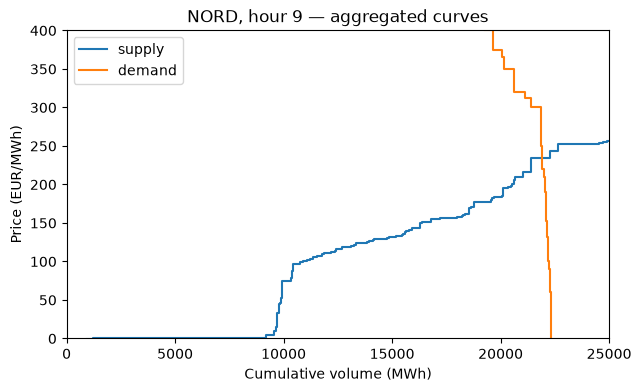

In [5]:
import matplotlib.pyplot as plt

supply = curves[(9, "NORD")]["supply"]
demand = curves[(9, "NORD")]["demand"]

fig, ax = plt.subplots(figsize=(7, 4))
supply.plot(ax=ax, label="supply")
demand.plot(ax=ax, label="demand")
ax.set_xlim(0, 25_000)
ax.set_ylim(0, 400)
ax.set_title("NORD, hour 9 — aggregated curves")
ax.legend()
plt.show()

The curves cross where the market clears. Note the vertical segments at the
extremes: price-taking volume that will be accepted at any price, including
the accepted block orders fixed at their published awarded quantity.

## 4. Internal transfer capacities

`set_ntc` sets how much power each link may carry, per hour and per
direction. These limits are what makes prices diverge between zones: when a
link saturates, the zones on either side stop sharing a price.

In [6]:
for row in capacities.itertuples():
    market.set_ntc(
        row.from_zone,
        row.to_zone,
        period=row.period,
        forward_capacity_mwh=row.forward_capacity_mwh,
        reverse_capacity_mwh=row.reverse_capacity_mwh,
    )

capacities.head()

,period,from_zone,to_zone,forward_capacity_mwh,reverse_capacity_mwh
0,1,CALA,SICI,1567.0,1048.0
1,1,CALA,SUD,2350.0,1733.0
2,1,CNOR,CSUD,4273.0,3106.0
3,1,CNOR,NORD,2868.0,3976.0
4,1,CSUD,SARD,720.0,870.0


## 5. Boundary conditions

Italy is not an island: it trades with France, Switzerland, Austria,
Slovenia, Greece, Montenegro and Corsica. Rather than model all of Europe,
we close the model at the border — and *how* we close it decides which
outcome we can reproduce.

**`add_fixed_price_boundary`** makes each border a *price taker* at the
neighbour's published price, free to trade anything within the published
border capacity (a Dirichlet condition). This is what pins the Italian
prices down, and it needs no exchange data at all.

**`add_fixed_flow_boundary`** instead pins a border at a known exchange
volume (a Neumann condition). We will need it in §9: a price-taking border
leaves the *volume* free, and a border volume that floats drags the internal
flows with it.

For prices, the price-taking closure is the one to use.

In [7]:
from openeuphemia.italy.replication import (
    external_boundary_prices,
    external_capacity_bounds,
    price_mapping,
)

prices_by_zone = price_mapping(published_prices, delivery_day=DAY)
neighbour_prices = {
    key: value for key, value in prices_by_zone.items() if key[1] not in ITALY_PRICE_AREAS
}

external_bounds = external_capacity_bounds(
    transfer_capacities,
    delivery_day=DAY,
    zones=ITALY_PRICE_AREAS,
)
border_prices, diagnostics = external_boundary_prices(external_bounds, neighbour_prices)

for row in border_prices.itertuples():
    market.add_fixed_price_boundary(
        id=row.id,
        period=row.period,
        zone=row.zone,
        external_zone=row.external_zone,
        price_eur_per_mwh=row.price_eur_per_mwh,
        import_capacity_mwh=row.import_capacity_mwh,
        export_capacity_mwh=row.export_capacity_mwh,
    )

print(f"{len(border_prices)} price-taking borders, "
      f"{(diagnostics.treatment == 'unpriced-dropped').sum()} dropped for lack of a price")
diagnostics.head()

288 price-taking borders, 0 dropped for lack of a price


,period,id,zone,external_zone,external_price_eur_per_mwh,import_capacity_mwh,export_capacity_mwh,treatment
0,1,AUST_NORD,NORD,AUST,105.3,10000.0,10000.0,open
1,1,CNOR_CORS,CNOR,CORS,105.3,150.0,150.0,open
2,1,COAC_SARD,SARD,COAC,105.3,20.0,125.0,open
3,1,CORS_SARD,SARD,CORS,105.3,150.0,150.0,open
4,1,COUP_NORD,NORD,COUP,105.3,10000.0,10000.0,open


## 6. Clear

The market is complete. Clearing maximizes welfare — the area between the
accepted demand and supply steps — subject to the zonal balance, the link
limits, and the border capacities. Zonal prices are the **dual values** of
the balance constraints, which is exactly how EUPHEMIA defines them.

In [8]:
result = market.clear(method="per-period-lp")
print(result.status, f"welfare {result.objective_value:,.0f} EUR")
result.prices.head(7)

optimal welfare 2,279,321,994 EUR


,period,zone,price_eur_per_mwh
0,1,CALA,105.3
1,1,CNOR,105.3
2,1,CSUD,105.3
3,1,NORD,105.3
4,1,SARD,105.3
5,1,SICI,105.3
6,1,SUD,105.3


## 7. Did we get the prices right?

Compare against the published Italian prices, hour by hour and zone by zone.

In [9]:
from openeuphemia.italy import compare_prices, summarize_price_comparison

italian_prices = {
    key: value for key, value in prices_by_zone.items() if key[1] in ITALY_PRICE_AREAS
}
comparison = compare_prices(result.prices, italian_prices, delivery_day=DAY)
summarize_price_comparison(comparison)

{'price_rows': 168,
 'matched_rows': 168,
 'exact_rows': 168,
 'price_mae_eur_per_mwh': 0.0,
 'price_max_abs_error_eur_per_mwh': 0.0}

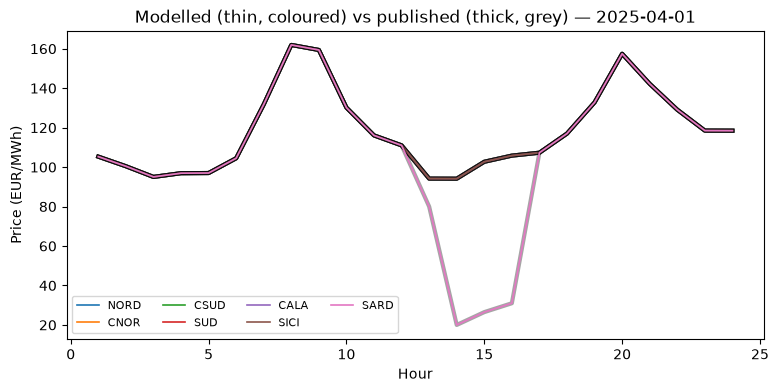

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for zone in ITALY_PRICE_AREAS:
    rows = comparison[comparison.zone == zone].sort_values("period")
    ax.plot(rows.period, rows.published_price_eur_per_mwh, lw=3, alpha=0.35, color="black")
    ax.plot(rows.period, rows.modelled_price_eur_per_mwh, lw=1.2, label=zone)
ax.set_xlabel("Hour")
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title(f"Modelled (thin, coloured) vs published (thick, grey) — {DAY}")
ax.legend(ncol=4, fontsize=8)
plt.show()

The coloured lines sit exactly on top of the grey ones — 168 of 168
zone-hours reproduced to the cent.

## 8. The whole month

One day could be luck. `replicate_italy_day` runs the same build-and-clear
we just did by hand, so we can sweep all 30 days of April 2025.

In [11]:
from openeuphemia.italy import delivery_days, replicate_italy_day

inputs = dict(
    bid_curves=bid_curves,
    transfer_capacities=transfer_capacities,
    published_prices=published_prices,
    published_flows=published_flows,
    published_exchanges=published_exchanges,
)
days = delivery_days(bid_curves)

month = pd.concat(
    [replicate_italy_day(delivery_day=day, **inputs).price_comparison for day in days],
    ignore_index=True,
)
summarize_price_comparison(month)

{'price_rows': 5040,
 'matched_rows': 5040,
 'exact_rows': 5040,
 'price_mae_eur_per_mwh': 0.0,
 'price_max_abs_error_eur_per_mwh': 0.0}

**5,040 of 5,040 zone-hours exact.** Given the published order book and
capacities, welfare maximization has a unique price solution, and it is the
one GME published. Note also what we did *not* need: France and Greece were
never modelled, only priced. The border prices are a sufficient statistic
for the rest of Europe.

---

## 9. The harder half: flows

Prices are unique. Flows are not.

Whenever two zones settle at the *same* price, the exchange between them is
genuinely indeterminate: many different flow patterns support the identical,
maximal welfare. The solver returns an arbitrary vertex of that optimal
face; GME published a specific point on it. Closing that gap needs a
**selection rule** — a secondary objective applied over the welfare optimum,
which by construction cannot disturb the prices.

First, one change of setup. A price-taking border is free to trade any
volume within its capacity, and inside that box many exchanges are
welfare-equal — so the border volume floats, and via the zonal balance it
drags the internal flows with it. To score flows we pin the borders at their
published exchange instead (`boundary="exchanges"`), which is the schedule
with the rest of Europe that Italy's clearing takes as given. That is an
*input* to Italy's problem — it says nothing about how flow is split
*between Italian zones*, which is what we are predicting.

In [12]:
from openeuphemia.italy import summarize_flow_comparison

RULES = [
    (None, "none — arbitrary optimal vertex"),
    ("volume-max", "volume maximization (documented)"),
    ("pro-rata", "pro-rata sharing (learned)"),
    ("anchored", "anchored to the schedule (reference)"),
]

ladder = []
for rule, label in RULES:
    comparisons = [
        replicate_italy_day(
            delivery_day=day, boundary="exchanges", flow_selection=rule, **inputs
        ).flow_comparison
        for day in days
    ]
    stats = summarize_flow_comparison(pd.concat(comparisons, ignore_index=True))
    ladder.append(
        {
            "rule": label,
            "flow MAE (MWh)": stats["flow_mae_mwh"],
            "max error (MWh)": stats["flow_max_abs_error_mwh"],
            "exact link-hours": f"{stats['exact_flow_rows']} / {stats['flow_rows']}",
        }
    )
    print(f"{label:<40} MAE {stats['flow_mae_mwh']:.4f} MWh")

ladder = pd.DataFrame(ladder)
ladder

none — arbitrary optimal vertex          MAE 2.8914 MWh


volume maximization (documented)         MAE 2.9013 MWh


pro-rata sharing (learned)               MAE 0.0012 MWh


anchored to the schedule (reference)     MAE 0.0001 MWh


,rule,flow MAE (MWh),max error (MWh),exact link-hours
0,none — arbitrary optimal vertex,2.891404,261.181000,3818 / 4320
1,volume maximization (documented),2.901284,346.521762,3814 / 4320
2,pro-rata sharing (learned),0.001155,0.099501,4208 / 4320
3,anchored to the schedule (reference),0.000087,0.047603,4311 / 4320


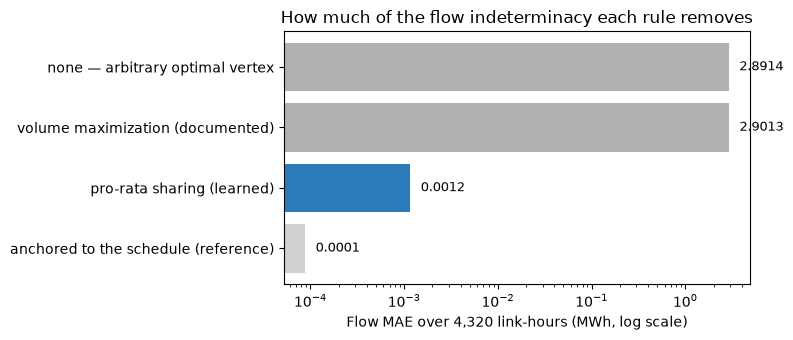

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#b0b0b0", "#b0b0b0", "#2b7bba", "#d0d0d0"]
ax.barh(ladder["rule"], ladder["flow MAE (MWh)"], color=colors)
ax.set_xscale("log")
ax.set_xlabel("Flow MAE over 4,320 link-hours (MWh, log scale)")
ax.invert_yaxis()
for y, value in enumerate(ladder["flow MAE (MWh)"]):
    ax.text(value * 1.3, y, f"{value:.4f}", va="center", fontsize=9)
ax.set_title("How much of the flow indeterminacy each rule removes")
plt.tight_layout()
plt.show()

Reading the ladder:

- **None** — an arbitrary optimal vertex is off by ~2.9 MWh on average, with
  individual link-hours out by hundreds of MWh. Welfare alone really does
  not determine the flows.
- **Volume maximization** — from EUPHEMIA's public description: among the
  welfare-optimal solutions, trade the zero-surplus matches too. It pins the
  *total* traded volume, but not how tied acceptance is split between zones,
  so the flow error barely moves.
- **Pro-rata sharing** — share the remaining tied same-price acceptance in
  proportion to submitted volume. This collapses the error by three orders
  of magnitude, to **0.0012 MWh** with the worst link-hour in the month off
  by 0.10 MWh. It consumes no outcome data: only per-zone at-price volumes,
  which the aggregated curves already contain.
- **Anchored** — minimize the distance to the published schedule itself.
  This *reads the answer*, so it is not a prediction; it is the floor on
  what any selection rule could achieve, and pro-rata sits essentially on
  top of it.

Two honest caveats. Pro-rata is **not in the public description** — it was
reverse-engineered from published outcomes, and whether it reflects an
undocumented sub-problem or generic solver behaviour cannot be determined
from outside. And it is **era-dependent**: before the 2025 abolition of the
PUN, the published splits instead follow the description's merit-order
priority rule, which needs per-offer merit-order numbers rather than
aggregated curves.

## What this shows

Both published outcomes of the Italian day-ahead market, reproduced from
public data:

| Outcome | Result | What it needs |
|---|---|---|
| Prices | 5,040 / 5,040 zone-hours exact | curves, capacities, neighbours' prices |
| Flows | 0.0012 MWh MAE over 4,320 link-hours | + border schedule, + a selection rule |

The two halves are different in kind. Prices follow from welfare
maximization alone — no rule, no tuning. Flows need a selection rule on top,
because the optimization leaves them open; and the rule that fits is one the
public description does not contain.

The same tables — curves, capacities, border prices, border exchanges — are
all any other bidding zone needs. Adding a region to OpenEUPHEMIA means
preparing them and proving the clearing reproduces what was published.